In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load processed weekly SKU demand
weekly_df = pd.read_csv('../data/processed/weekly_sku_demand.csv')
weekly_df['Week_Start'] = pd.to_datetime(weekly_df['Week_Start'])

# Sort chronologically to preserve time structure
weekly_df = weekly_df.sort_values(['StockCode', 'Week_Start']).reset_index(drop=True)

print(f"Loaded {len(weekly_df):,} weekly records across {weekly_df['StockCode'].nunique()} qualified SKUs.")

Loaded 127,038 weekly records across 1676 qualified SKUs.


In [2]:
# Select single representative high-volume SKU for initial baseline modeling
top_sku = weekly_df.groupby('StockCode')['Quantity'].sum().idxmax()
sku_data = weekly_df[weekly_df['StockCode'] == top_sku].copy().reset_index(drop=True)

# Chronological split: 80% Train, 10% Validation, 10% Test
n = len(sku_data)
train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_df = sku_data.iloc[:train_end].copy()
val_df = sku_data.iloc[train_end:val_end].copy()
test_df = sku_data.iloc[val_end:].copy()

print(f"Target SKU: {top_sku}")
print(f"Train Period: {train_df['Week_Start'].min().date()} to {train_df['Week_Start'].max().date()} ({len(train_df)} weeks)")
print(f"Val Period:   {val_df['Week_Start'].min().date()} to {val_df['Week_Start'].max().date()} ({len(val_df)} weeks)")
print(f"Test Period:  {test_df['Week_Start'].min().date()} to {test_df['Week_Start'].max().date()} ({len(test_df)} weeks)")

Target SKU: 84077
Train Period: 2009-12-07 to 2011-07-18 (82 weeks)
Val Period:   2011-07-25 to 2011-09-26 (10 weeks)
Test Period:  2011-10-03 to 2011-12-12 (11 weeks)


In [3]:
# 1. Naive Forecast: Assumes next period demand equals previous period demand
val_df['Forecast_Naive'] = val_df['Quantity'].shift(1)
# Fill first value of validation split with last known training observation
val_df['Forecast_Naive'] = val_df['Forecast_Naive'].fillna(train_df['Quantity'].iloc[-1])

# 2. Moving Average (4-Week Rolling Mean)
val_df['Forecast_MA4'] = train_df['Quantity'].tail(4).mean()

# 3. Seasonal Naive (Assumes demand equals demand from 52 weeks ago, or available historical lag)
# Since dataset spans ~104 weeks, we use 52-week seasonal lag
val_df['Forecast_SNaive'] = sku_data['Quantity'].shift(52).iloc[train_end:val_end].values
val_df['Forecast_SNaive'] = val_df['Forecast_SNaive'].fillna(train_df['Quantity'].mean())

val_df[['Week_Start', 'Quantity', 'Forecast_Naive', 'Forecast_MA4', 'Forecast_SNaive']].head()

,Week_Start,Quantity,Forecast_Naive,Forecast_MA4,Forecast_SNaive
82,2011-07-25,1016,432.0,770.25,1495.0
83,2011-08-01,485,1016.0,770.25,337.0
84,2011-08-08,194,485.0,770.25,790.0
85,2011-08-15,625,194.0,770.25,3130.0
86,2011-08-22,432,625.0,770.25,481.0


In [4]:
def calculate_metrics(y_true, y_pred, model_name):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    
    return {
        'Model': model_name,
        'MAE (Units)': round(mae, 2),
        'RMSE (Units)': round(rmse, 2),
        'WAPE (%)': round(wape, 2)
    }

# Evaluate all three baselines on Validation Split
metrics_list = [
    calculate_metrics(val_df['Quantity'], val_df['Forecast_Naive'], 'Naive Forecast'),
    calculate_metrics(val_df['Quantity'], val_df['Forecast_MA4'], '4-Week Moving Average'),
    calculate_metrics(val_df['Quantity'], val_df['Forecast_SNaive'], 'Seasonal Naive')
]

baseline_results = pd.DataFrame(metrics_list)
print("=== BASELINE MODEL PERFORMANCE (VALIDATION SET) ===")
display(baseline_results)

=== BASELINE MODEL PERFORMANCE (VALIDATION SET) ===


,Model,MAE (Units),RMSE (Units),WAPE (%)
0,Naive Forecast,489.4,543.46,75.69
1,4-Week Moving Average,325.5,355.09,50.34
2,Seasonal Naive,765.9,1137.43,118.45


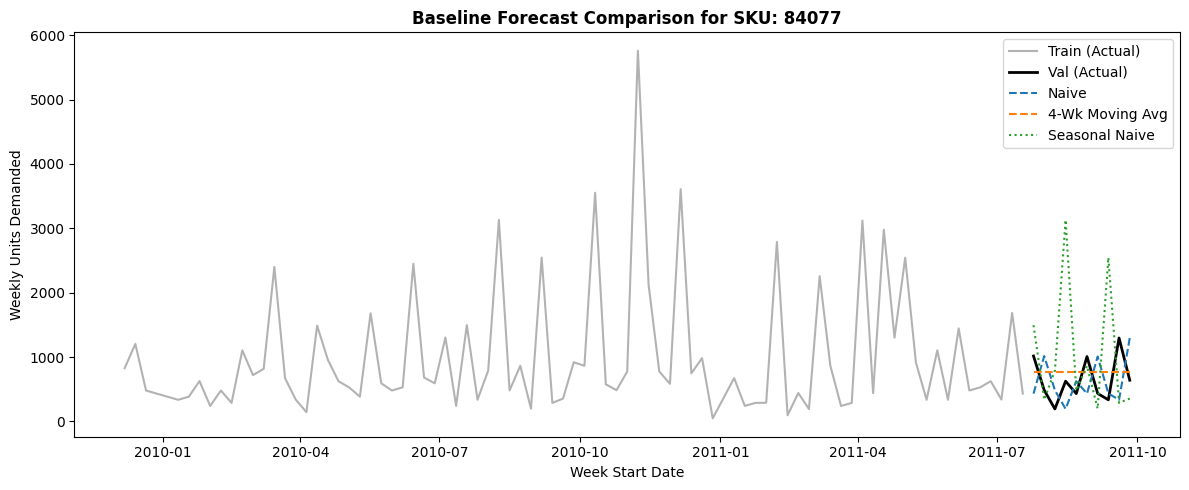

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(train_df['Week_Start'], train_df['Quantity'], label='Train (Actual)', color='gray', alpha=0.6)
plt.plot(val_df['Week_Start'], val_df['Quantity'], label='Val (Actual)', color='black', linewidth=2)
plt.plot(val_df['Week_Start'], val_df['Forecast_Naive'], label='Naive', linestyle='--')
plt.plot(val_df['Week_Start'], val_df['Forecast_MA4'], label='4-Wk Moving Avg', linestyle='--')
plt.plot(val_df['Week_Start'], val_df['Forecast_SNaive'], label='Seasonal Naive', linestyle=':')

plt.title(f'Baseline Forecast Comparison for SKU: {top_sku}', fontsize=12, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Weekly Units Demanded')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os

results_dir = '../reports/results'

# If a file named 'results' exists instead of a folder, remove it
if os.path.exists(results_dir) and not os.path.isdir(results_dir):
    os.remove(results_dir)

# Create the results directory properly
os.makedirs(results_dir, exist_ok=True)

# Save validation performance benchmark
output_file = os.path.join(results_dir, 'baseline_performance.csv')
baseline_results.to_csv(output_file, index=False)

print(f"Baseline performance metrics saved to {output_file} successfully.")

FileExistsError: [WinError 183] Cannot create a file when that file already exists: '../reports/results'